In [1]:
import sys
sys.path.append("/RAFT-Stereo")
import numpy as np
import time
import pfmread
import cv2
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn.functional as F
def depth_to_normal_map(depth_map: torch.Tensor, fx: float, fy: float):
    # Calculate depth map gradients in x and y directions using Sobel filter
    dz_dx = F.conv2d(depth_map.unsqueeze(0).unsqueeze(0), torch.tensor([[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]], device=depth_map.device, dtype=depth_map.dtype) / 8, padding=1).squeeze()
    dz_dy = F.conv2d(depth_map.unsqueeze(0).unsqueeze(0), torch.tensor([[[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]]], device=depth_map.device, dtype=depth_map.dtype) / 8, padding=1).squeeze()
    
    # Calculate normal vectors
    normal_x = -dz_dx / fx
    normal_y = -dz_dy / fy
    normal_z = torch.ones_like(depth_map)

    normals = torch.stack((normal_x, normal_y, normal_z), dim=-1)
    norm = torch.norm(normals, dim=-1, keepdim=True)
    normals = normals / (norm + 1e-8)  # Normalize and prevent division by zero

    # Convert to RGB format (normalized to range 0~1)
    normal_map = (normals + 1) / 2
    return normal_map
def render_diffuse(normal_map: torch.Tensor, light_direction: torch.Tensor):
    # Calculate the dot product between the normal map and the light direction
    diffuse = torch.clamp(torch.sum(normal_map * -light_direction, dim=-1), 0, 1)
    return diffuse

def render_specular(normal_map: torch.Tensor, light_direction: torch.Tensor, view_direction: torch.Tensor, shininess: float):
    # Calculate the reflection direction
    reflection = 2 * torch.sum(normal_map * -light_direction, dim=-1, keepdim=True) * normal_map - light_direction

    # Calculate the dot product between the reflection direction and the view direction
    specular = torch.clamp(torch.sum(reflection * view_direction, dim=-1), 0, 1) ** shininess
    return specular

def compute_pointcloud(K: torch.Tensor, depth_map: torch.Tensor):
    height, width = depth_map.shape
    y, x = torch.meshgrid(torch.arange(height, device=depth_map.device), torch.arange(width, device=depth_map.device), indexing="ij")

    # Use camera intrinsic parameters fx, fy
    fx, fy = K[0, 0], K[1, 1]
    p_x = (x - width / 2) / fx * depth_map
    p_y = (y - height / 2) / fy * depth_map
    p_z = depth_map
    points = torch.stack((p_x, p_y, p_z), dim=-1)
    return points

def render_attenuation(K: torch.Tensor, depth_map: torch.Tensor, light_position: torch.Tensor, attenuation_factor: float = 1.0):
    points = compute_pointcloud(K, depth_map)
    # Calculate distance to the light source
    light_distance = torch.norm(points - light_position, dim=-1)

    # Calculate attenuation based on distance to the light source
    attenuation = 1 / (1 + attenuation_factor * light_distance ** 2)

    return attenuation, light_distance

def compute_spot_factor(light_direction: torch.Tensor, spot_direction: torch.Tensor, spot_exponent: float, cutoff_angle: float):
    # Calculate the angle between the light direction and spotlight direction
    cos_angle = light_direction* spot_direction.unsqueeze(0).unsqueeze(0)

    # Calculate the spotlight attenuation factor based on the cutoff angle
    spot_factor = torch.clamp((cos_angle - torch.cos(torch.tensor(cutoff_angle))) / (torch.cos(torch.tensor(spot_exponent)) - torch.cos(torch.tensor(cutoff_angle))), 0, 1)
    return spot_factor

def render(K: torch.Tensor, depth_map: torch.Tensor, light_position: torch.Tensor, view_direction: torch.Tensor, shininess: float, texture: torch.Tensor, intensity: float = 1.0, spot_exp=torch.pi / 4, spot_cutoff= torch.pi / 16):
    fx, fy = K[0, 0], K[1, 1]
    normal_map = depth_to_normal_map(depth_map.clone(), fx, fy)
    points = compute_pointcloud(K, depth_map)
    light_direction = light_position - points

    light_direction = light_direction / torch.norm(light_direction, dim=-1, keepdim=True)

    diffuse = render_diffuse(normal_map, light_direction.clone())

    specular = render_specular(normal_map, light_direction.clone(), view_direction, shininess)
    spot_factor = compute_spot_factor(-light_direction.clone(), view_direction, spot_exp, spot_cutoff)
    attenuation, light_distance = render_attenuation(K, depth_map, light_position)

    return (intensity  * attenuation * (diffuse + specular)  * (1-spot_factor[...,-1]))[..., None] * texture, [depth_map, diffuse, specular, spot_factor, attenuation, light_distance]
def peusdo_nir(rgb):
    # Reverse the channels and use torch.maximum
    interm = torch.maximum(rgb, 1 - rgb)

    # Compute the weighted sum and apply the power operation
    nir = (
        interm[..., 0] * 0.229 + interm[..., 1] * 0.587 + interm[..., 2] * 0.114
    ) ** (1 / 0.25)

    return nir

In [3]:
class ImageItem:
    image: torch.Tensor
    depth_map: torch.Tensor
    material: torch.Tensor
    def __init__(self, image, depth_map, material):
        self.image = image
        self.depth_map = depth_map
        self.material = material

import random     

def random_light_render(K_tensor, baseline, item_left, item_right, depth_range= [3,30], intensity_range=[2,8], spot_exp = np.pi / 4):
    device = K_tensor.device
    image_left, depth_map_left, _ = item_left.image, item_left.depth_map, item_left.material
    image_right, depth_map_right, _ = item_right.image, item_right.depth_map, item_right.material
    shaded_left = torch.zeros_like(image_left, dtype=torch.float32).to(device)
    shaded_right = torch.zeros_like(image_right, dtype=torch.float32).to(device)

    for i in range(20):
        light_z = random.randint(*depth_range)
        intensity = 2 ** random.randint(*intensity_range)
        shininess=64
        light_position = torch.tensor([random.randrange(-1, 1) * (light_z), random.randrange(-2, 1) * light_z, light_z], dtype=torch.float32).to(device)
        shaded, _ = render(K_tensor, depth_map_left, light_position=light_position + torch.tensor([baseline / 2, 0, 0], dtype=torch.float32).to(device), view_direction=torch.tensor([0, 0, 1], dtype=torch.float32).to(device), shininess=shininess, texture=image_left / 255, intensity=intensity, spot_exp=spot_exp)
        shaded_left += shaded
        shaded, _ = render(K_tensor, depth_map_right, light_position=light_position - torch.tensor([baseline / 2, 0, 0], dtype=torch.float32).to(device), view_direction=torch.tensor([0, 0, 1], dtype=torch.float32).to(device), shininess=shininess, texture=image_right / 255, intensity=intensity, spot_exp=spot_exp)
        shaded_right += shaded
    shaded_left = torch.clip(shaded_left-0.1, 0, 1)
    shaded_right = torch.clip(shaded_right-0.1, 0, 1)
    return shaded_left, shaded_right

In [26]:
device = 'cuda:0'
def random_nir_render(item_left: ImageItem, item_right : ImageItem, K_tensor: torch.Tensor, baseline = 1):
    
    light_position = torch.tensor([0, random.randint(-3,3), -2]).to(device)
    intensity = random.randint(10,30)
    spot_exp = torch.pi / (random.randint(2,5))
    left, _ = render(
        K_tensor,
        item_left.depth_map,
        light_position=light_position
        + torch.tensor([baseline / 2, 0, 0], dtype=torch.float32).to(device),
        view_direction=torch.tensor([0, 1, 1], dtype=torch.float32).to(device),
        shininess=16,
        texture=(item_left.material /256 if item_left.material is not None else 1) * peusdo_nir(item_left.image / 255)[...,None],
        intensity=intensity,
        spot_exp=spot_exp,
        spot_cutoff=torch.pi / 16
    )
    right, _ = render(
        K_tensor,
        item_right.depth_map,
        light_position=light_position
        - torch.tensor([baseline / 2, 0, 0], dtype=torch.float32).to(device),
        view_direction=torch.tensor([0, 0, 1], dtype=torch.float32).to(device),
        shininess=16,
        texture=(item_right.material /256 if item_right.material is not None else 1) * peusdo_nir(item_right.image / 255)[...,None],
        intensity=intensity,
        spot_exp=spot_exp,
        spot_cutoff=torch.pi / 16
    )
    return torch.clip(left-0.1,0,1),torch.clip(right-0.1,0,1)

In [5]:
def read_flying3d_frame(
    frame_path: str,
    term="normal_map",
    K=np.array([[1050.0, 0.0, 479.5], [0.0, 1050.0, 269.5], [0.0, 0.0, 1.0]]),
    baseline=1,
):
    disparity_map = pfmread.read(
        frame_path.replace(term, "disparity").replace(".png", ".pfm")
    )
    image_left = cv2.imread(
        frame_path.replace(term, "frames_cleanpass").replace("pfm", "png")
    )
    material_index = pfmread.read(
        frame_path.replace(term, "material_index").replace(".png", ".pfm")
    )[..., np.newaxis]
    image_right = cv2.imread(
        frame_path.replace(term, "frames_cleanpass")
        .replace("left", "right")
        .replace("pfm", "png")
    )
    disparity_map_right = pfmread.read(
        frame_path.replace(term, "disparity")
        .replace("left", "right")
        .replace(".png", ".pfm")
    )
    material_index_right = pfmread.read(
        frame_path.replace(term, "material_index")
        .replace("left", "right")
        .replace(".png", ".pfm")
    )[..., np.newaxis]
    import matplotlib.pyplot as plt

    image_left = torch.from_numpy(image_left).float()
    image_right = torch.from_numpy(image_right).float()

    disparity_map = torch.from_numpy(disparity_map.copy())
    disparity_map_right = torch.from_numpy(disparity_map_right.copy())
    material_index = torch.from_numpy(material_index.copy())
    material_index_right = torch.from_numpy(material_index_right.copy())

    depth_map = K[0, 0] * baseline / disparity_map
    depth_map_right = K[0, 0] * baseline / disparity_map_right
    return ImageItem(
        image_left.cuda(), depth_map.cuda(), material_index.cuda()
    ), ImageItem(
        image_right.cuda(), depth_map_right.cuda(), material_index_right.cuda()
    )

In [6]:
def intepolate(disparity_left, occ_mask):
    # Convert disparity and mask to appropriate shapes for grid_sample
    H, W = disparity_left.shape
    disparity_left = disparity_left.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    valid_mask = (occ_mask <240).float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

    # Detect invalid regions to interpolate
    invalid_mask = 1 - valid_mask

    # Generate normalized grid for grid_sample [-1, 1] range
    coords = torch.meshgrid(torch.linspace(-1, 1, H, device=disparity_left.device), 
                            torch.linspace(-1, 1, W, device=disparity_left.device), 
                            indexing='ij')
    grid = torch.stack(coords, dim=-1).unsqueeze(0)  # [1, H, W, 2]

    # Perform bilinear interpolation using grid_sample
    interpolated_disparity = F.grid_sample(disparity_left * valid_mask, grid, 
                                        mode='bilinear', padding_mode='border', align_corners=True)

    # Combine original and interpolated values
    disparity_left = disparity_left * valid_mask + interpolated_disparity * invalid_mask
    return disparity_left

def read_eth3d_frame(frame_path: str):
    cal = {}
    with open(f"{frame_path}/calib.txt", 'r') as file:
        lines = file.readlines()
        for line in lines:
            # 각 줄을 '='를 기준으로 분할
            key, value = line.strip().split('=')
            key = key.strip()
            cal[key] = value
    K = np.array([list(map(float, row.split())) for row in cal['cam0'].strip('[]').split(';')])
    baseline = float(cal['baseline'])
    image_left = cv2.imread(f"{frame_path}/im0.png")
    image_right = cv2.imread(f"{frame_path}/im1.png")
    disparity_left = pfmread.read(f"{frame_path}/disp0GT.pfm").copy()
    
    occ_mask = cv2.imread(f"{frame_path}/mask0nocc.png", cv2.IMREAD_GRAYSCALE).astype(np.uint8)
    plt.figure(figsize=(10,5))
    plt.subplot(131)
    plt.imshow(image_left)
    plt.subplot(132)
    plt.imshow(disparity_left, cmap="magma")
    plt.subplot(133)
    plt.imshow(occ_mask, cmap="gray")
    plt.show()
    invalid_mask = np.zeros_like(occ_mask, dtype=np.uint8)
    invalid_mask[occ_mask < 200] = 255
    disparity_left[invalid_mask > 0] = 0
    disparity_left = cv2.inpaint(disparity_left, invalid_mask.copy(), 1, cv2.INPAINT_NS)
    
    disparity_left = torch.from_numpy(disparity_left).cuda().float()

    
    
    depth_map = K[0,0] * baseline / disparity_left
    return ImageItem(torch.from_numpy(image_left).float().cuda(), depth_map, None),ImageItem(torch.from_numpy(image_left).float().cuda(), depth_map, None), (K, baseline), invalid_mask
    

In [28]:
import os
def flying3d_frame_augment(frame_path: str, term="normal_map"):
    item_left, item_right = read_flying3d_frame(frame_path, term)
    for i in range(10):
        shaded_left, shaded_right = random_light_render(
            K_tensor,
            baseline,
            item_left,
            item_right,
            intensity_range=[2,9],
            depth_range=[-10,30],
            spot_exp=np.pi/6
        )
        store_path_left = frame_path.replace(term, "frame_shaded").replace(".pfm",".png").replace(".png", f"_{i}.png")
        store_path_right = store_path_left.replace("left", "right")
        os.makedirs(os.path.dirname(store_path_left), exist_ok=True)
        os.makedirs(os.path.dirname(store_path_right), exist_ok=True)
        cv2.imwrite(store_path_left, (shaded_left.cpu().numpy() * 255).astype(np.uint8))
        cv2.imwrite(store_path_right, (shaded_right.cpu().numpy() * 255).astype(np.uint8))
        
        nir_left, nir_right = random_nir_render(item_left, item_right, K_tensor)
        store_path_left = store_path_left.replace("frame_shaded","frame_shaded_nir")
        store_path_right = store_path_left.replace("left", "right")
        os.makedirs(os.path.dirname(store_path_left), exist_ok=True)
        os.makedirs(os.path.dirname(store_path_right), exist_ok=True)
        cv2.imwrite(store_path_left, (np.clip(nir_left.cpu().numpy(), 0, 1) * 255).astype(np.uint8))
        cv2.imwrite(store_path_right, (np.clip(nir_right.cpu().numpy(), 0, 1) * 255).astype(np.uint8))

In [17]:
ROOT = "/bean/flow3d/frames_cleanpass/15mm_focallength"
paths = []
for subdir in os.listdir(ROOT):
    for subsubdir in os.listdir(os.path.join(ROOT, subdir)):
        for frame in os.listdir(os.path.join(ROOT, subdir,  subsubdir, "left")):
            paths.append(os.path.join(ROOT, subdir, subsubdir,  "left",frame))
print(len(paths)) 

2202


In [29]:
from tqdm.notebook import tqdm

for path in tqdm(paths):
    try:
        #if os.path.exists(path.replace("frames_cleanpass", "frame_shaded").replace(".pfm",".png").replace(".png", "_0.png")):
        #    continue
        flying3d_frame_augment(path,"frames_cleanpass")
    except Exception as e:
        print(path , "failed", e)

  0%|          | 0/2202 [00:00<?, ?it/s]

/bean/flow3d/frames_cleanpass/15mm_focallength/scene_backwards/fast/left/Thumbs.db failed don't know how to read /bean/flow3d/disparity/15mm_focallength/scene_backwards/fast/left/Thumbs.db
/bean/flow3d/frames_cleanpass/15mm_focallength/scene_forwards/fast/left/Thumbs.db failed don't know how to read /bean/flow3d/disparity/15mm_focallength/scene_forwards/fast/left/Thumbs.db


In [8]:
from myutils.disparity import get_raft_stereo
import os
os.chdir("/RAFT-Stereo")

raft_model = get_raft_stereo().cuda()

/tmp/ipykernel_2525382/1335968346.py:16: RuntimeWarning: invalid value encountered in cast
  plt.imshow(peusdo_nir(item_left.image.cpu()).numpy().astype(np.uint8), cmap="gray")
/tmp/ipykernel_2525382/1335968346.py:18: RuntimeWarning: invalid value encountered in cast
  plt.imshow(peusdo_nir(item_right.image.cpu()).numpy().astype(np.uint8), cmap="gray")


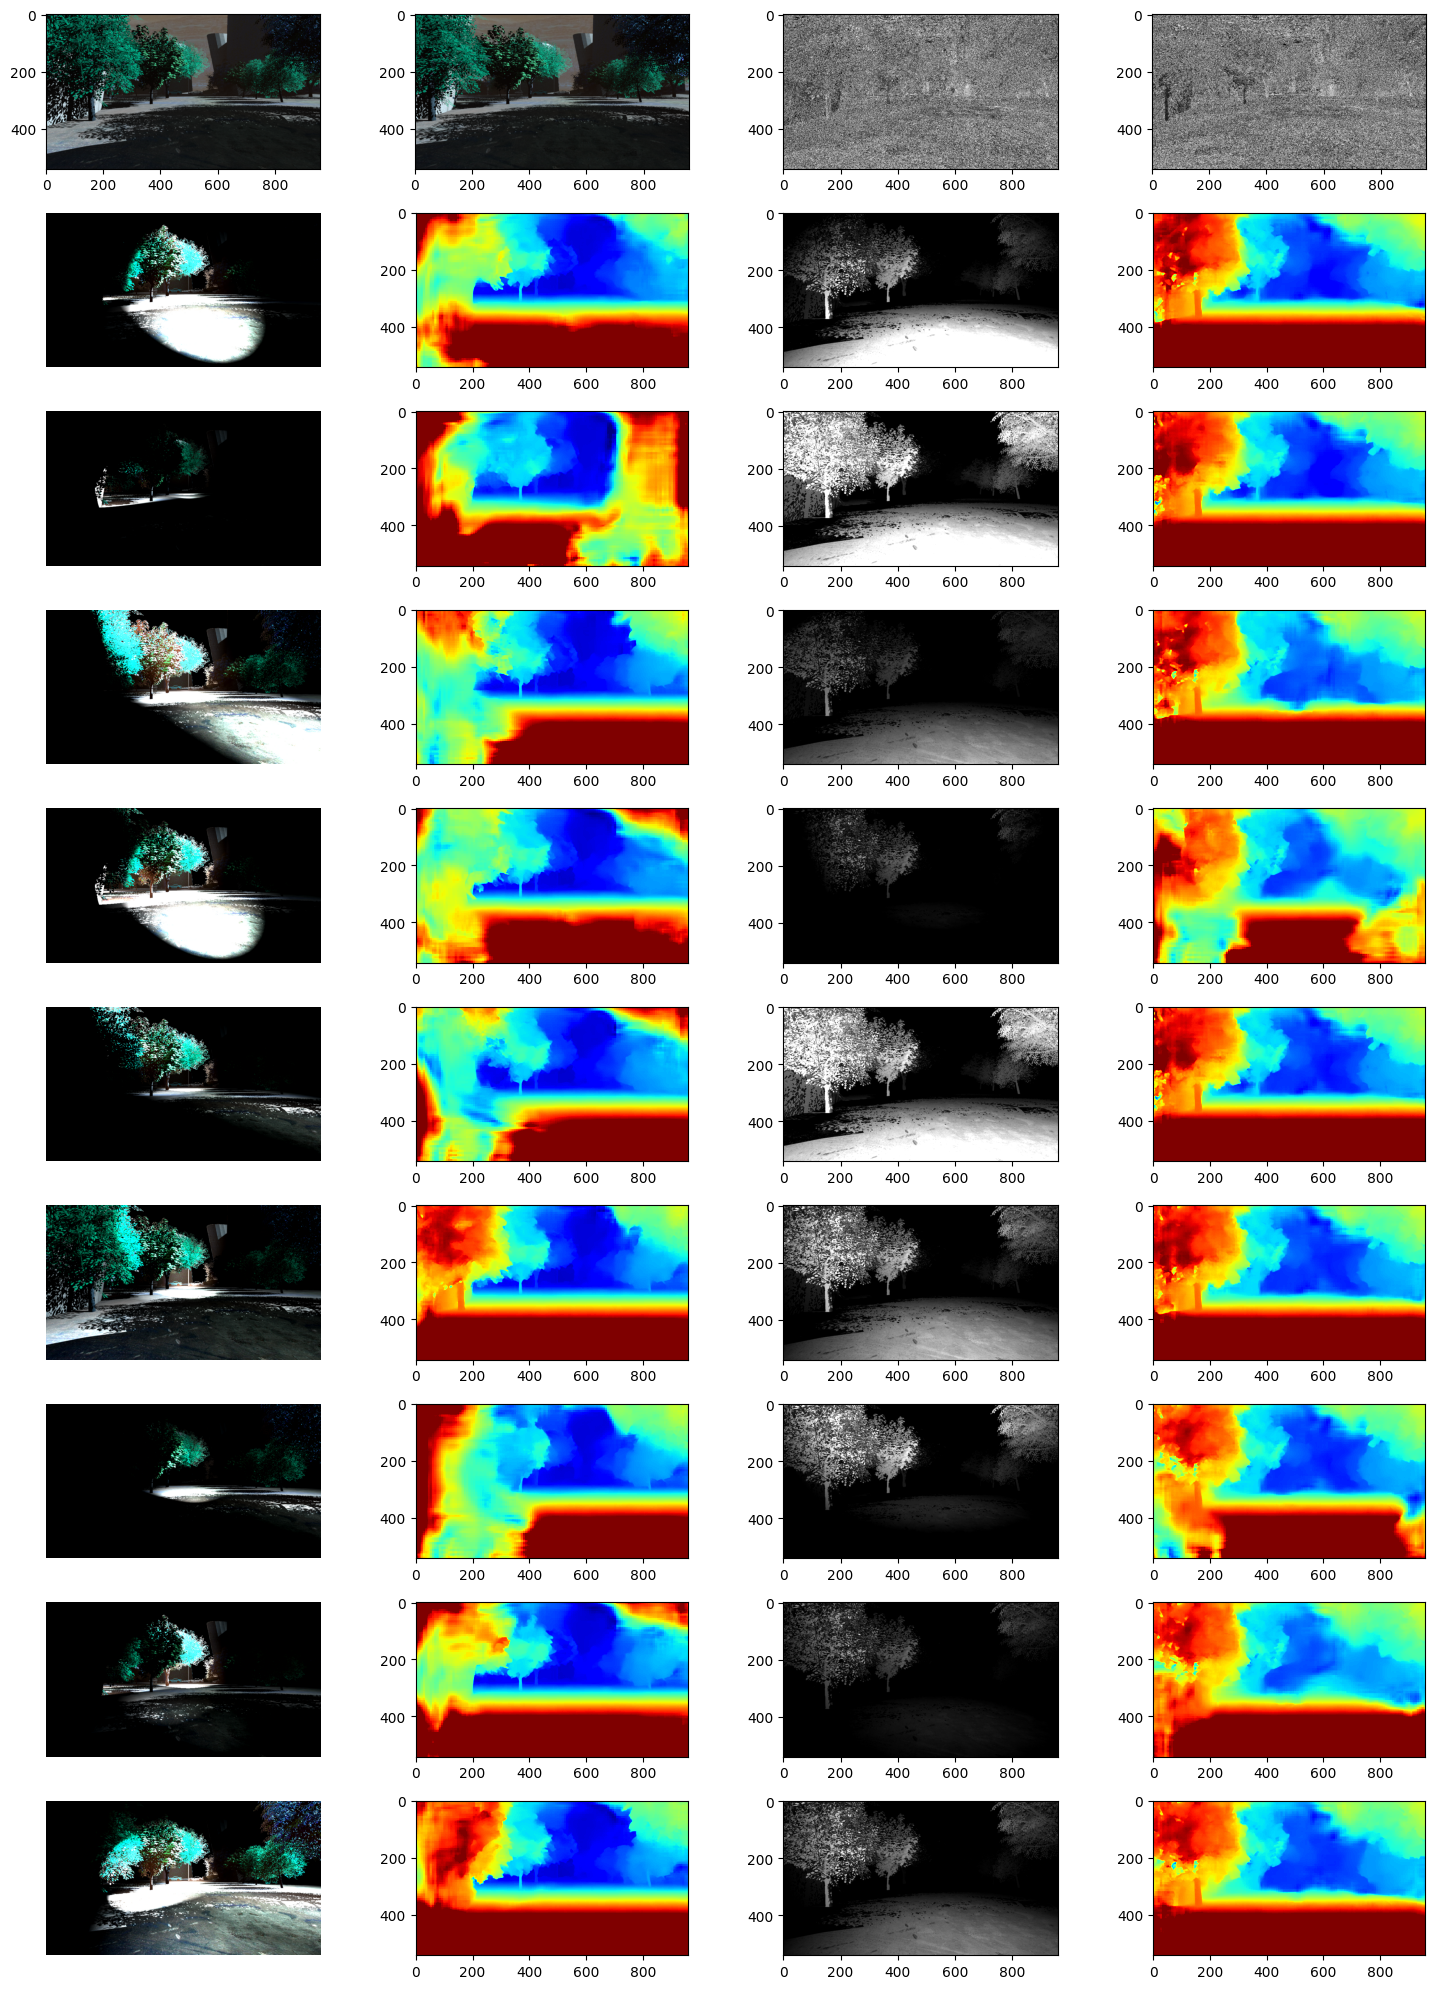

In [27]:
K=np.array([[450, 0.0, 479.5], [0.0, 450, 269.5], [0.0, 0.0, 1.0]])
#K=np.array([[1050.0, 0.0, 479.5], [0.0, 1050.0, 269.5], [0.0, 0.0, 1.0]])
baseline = 1
item_left, item_right = read_flying3d_frame("/bean/flow3d/frames_cleanpass/15mm_focallength/scene_forwards/fast/left/0088.png", "frames_cleanpass", K)
#item_left, item_right = read_flying3d_frame("/bean/flyingthings3d/normal_map/TRAIN/A/0022/left/0006.pfm", "normal_map", K)
#item_left, item_right, (K,baseline), occ_mask = read_eth3d_frame("/bean/eth3d/stereo/playground_3l")

K_tensor = torch.tensor(K).to(device)
plt.figure(figsize=(15, 20))
plt.subplot(10, 4, 1)
plt.imshow(item_left.image.cpu().numpy().astype(np.uint8))

plt.subplot(10, 4, 2)
plt.imshow(item_right.image.cpu().numpy().astype(np.uint8))
plt.subplot(10, 4, 3)
plt.imshow(peusdo_nir(item_left.image.cpu()).numpy().astype(np.uint8), cmap="gray")
plt.subplot(10, 4, 4)
plt.imshow(peusdo_nir(item_right.image.cpu()).numpy().astype(np.uint8), cmap="gray")
for i in range(1, 10):
    plt.subplot(10, 4, i * 4 + 1)
    shaded_left, shaded_right = random_light_render(
        K_tensor,
        baseline,
        item_left,
        item_right,
        intensity_range=[2,9],
        depth_range=[-10,30],
        spot_exp=np.pi/6
    )
    shaded_nir, shaded_nir_right = random_nir_render(item_left,
        item_right,K_tensor)
    plt.imshow(shaded_left.cpu(),  vmin=0, vmax=1)
    plt.axis("off")
    #plt.subplot(10, 4, i * 4 + 2)
    #plt.imshow(shaded_right.cpu(),  vmin=0, vmax=1)
    #plt.axis("off")
    
    
    with torch.no_grad():
        disp = -raft_model(shaded_left.permute(2,0,1).unsqueeze(0) * 255, shaded_right.permute(2,0,1).unsqueeze(0)* 255)[1][0,0]
        disp_nir = -raft_model(shaded_nir.permute(2,0,1).repeat(3,1,1).unsqueeze(0) * 255, shaded_nir_right.permute(2,0,1).repeat(3,1,1).unsqueeze(0)* 255)[1][0,0]
    plt.subplot(10, 4, i * 4 + 2)
    plt.imshow(disp.cpu(), vmin=0, vmax=128, cmap='jet')
    plt.subplot(10, 4, i * 4 + 3)
    plt.imshow(shaded_nir.cpu(), cmap="gray",  vmin=0, vmax=1)
    # plt.axis("off")
    
    plt.subplot(10, 4, i * 4 + 4)
    plt.imshow(disp_nir.cpu(), vmin=0, vmax=128, cmap='jet')
    # plt.imshow(shaded_nir_right.cpu(), cmap="gray", vmin=0, vmax=1)
    # plt.axis("off")
plt.tight_layout()
plt.show()